In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import empty
import xarray as xr
import pftnames
import cftime
import utils
import grainc_global
from scipy import stats, signal
import HS_functions
import cartopy.crs as ccrs
import regionmask
import glob
import os
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm

79


In [3]:
def merge_annual_datasets_multivar(path_in, YR1, YR2, historyfile='h0'):

    # --------------------------------------------------
    #  find files
    # --------------------------------------------------
    pattern = os.path.join(path_in, f"*clm2.{historyfile}.*.nc")
    files_all = sorted(glob.glob(pattern))
    
    
    if len(files_all) == 0:
        raise FileNotFoundError(f"No files found matching {pattern}")

    files = []
    for f in files_all:
        try:
            year = int(f.split('.')[-2].split('-')[0])
            if YR1 <= year <= YR2:
                files.append(f)
        except Exception:
            continue

    if len(files) == 0:
        raise ValueError(f"No files found between {YR1} and {YR2}")
    # --------------------------------------------------
    # Open sequentially
    # --------------------------------------------------
    datasets = []
    for f in files:
        ds = xr.open_dataset(f)
        datasets.append(ds)

    # --------------------------------------------------
    # Concatenate along time
    # --------------------------------------------------
    ds_merged = xr.concat(datasets, dim="time")

    return ds_merged

In [4]:
def datetime64_to_cftime(ds):
    """
    Convert a dataset with datetime64[ns] time to cftime.DatetimeNoLeap (first of month)
    """
    # Convert numpy.datetime64 array to pandas DatetimeIndex
    time_index = pd.to_datetime(ds['time'].values)

    # Construct cftime.DatetimeNoLeap objects for first of each month
    cftime_times = np.array([cftime.DatetimeNoLeap(t.year, t.month, 1) for t in time_index])

    # Assign back to dataset
    ds = ds.assign_coords(time=("time", cftime_times))
    return ds

In [2]:
def shift_time_back_one_month(ds):
    new_times = []
    for t in ds['time'].values:
        year = t.year
        month = t.month - 1  # previous month
        if month == 0:  # if January, go to December of previous year
            month = 12
            year -= 1
        new_times.append(cftime.DatetimeNoLeap(year, month, 1))
    ds_shifted = ds.assign_coords(time=("time", np.array(new_times)))
    return ds_shifted

In [5]:
#paths
YR1, YR2 = 2000, 2014
path_clm = f'/apps/CTSM_dev/DERECHO_OUT/HSF_TVPK_REP/exp10/'
path_list = f'/data/processed/lst_esacci_modis_2deg/'
dsland = xr.open_dataset(f'../inputdata/lnd/clm2/surfdata_esmf/ctsm5.2.0/surfdata_1.9x2.5_hist_1850_78pfts_c240216.nc')

In [9]:
ds_clm   = merge_annual_datasets_multivar(path_clm, YR1,YR2, 'h0')

In [29]:
# ----------- load in area map
PCT_CROP = dsland['PCT_CROP'] 

# ----------- load in CLM ds
ds_clm   = merge_annual_datasets_multivar(path_clm, YR1,YR2, 'h0')
#ds_clm['time']  = ds_clm.time.dt.month-1
PCT_CROP = (
    PCT_CROP
    .rename({"lsmlat": "lat", "lsmlon": "lon"})
    .assign_coords(lat=ds_clm['lat'], lon=ds_clm['lon'])
)
LANDFRAC = utils.lon_pm2idl(ds_clm['landfrac'])  #==1
LAI      =  utils.lon_pm2idl(ds_clm['ELAI'].where(PCT_CROP>5)).where(LANDFRAC==1)
TV      =  utils.lon_pm2idl(ds_clm['TV'].where(PCT_CROP>5)).where(LANDFRAC==1).where(LAI>0.3)
TSKIN    =  utils.lon_pm2idl(ds_clm['TSKIN'].where(PCT_CROP>5)).where(LANDFRAC==1).where(LAI>0.3)
# ----------- load in ESA CCI MODIS LST
LSTD = utils.lon_pm2idl(xr.open_dataset(f'{path_list}LSTD_{YR1}_{YR2}.nc'))
LSTN = utils.lon_pm2idl(xr.open_dataset(f'{path_list}LSTN_{YR1}_{YR2}.nc'))
LSTN, LSTD = LSTN.where(LSTD>0).assign_coords(lat=TSKIN ['lat'], lon=TSKIN ['lon']), LSTD.where(LSTN>0).assign_coords(lat=TSKIN ['lat'], lon=TSKIN ['lon'])
LSTN, LSTD = LSTN.where(TSKIN.max(dim='time')>0), LSTD.where(TSKIN.max(dim='time')>0)
# approach daily mean
mask_valid = np.isfinite(LSTD['lst']) & np.isfinite(LSTN['lst'])
LSTM = xr.where(mask_valid, (LSTD['lst'] + LSTN['lst']) / 2, np.nan)
#LSTM = (LSTD['lst'] + LSTN['lst'] ) / 2

#remoe frozen soils
LSTM = LSTM.where(LSTM>278.15)
TSKIN = TSKIN.where(TSKIN>278.15)
TV    = TV.where(TSKIN>278.15)

# match on time
TSKIN = shift_time_back_one_month(TSKIN)  # clm5 timestamps represent start of the month; filename represent actual month
TV    =  shift_time_back_one_month(TV)
LSTM = datetime64_to_cftime(LSTM)
TSKIN, LSTM = xr.align(TSKIN, LSTM, join="inner")

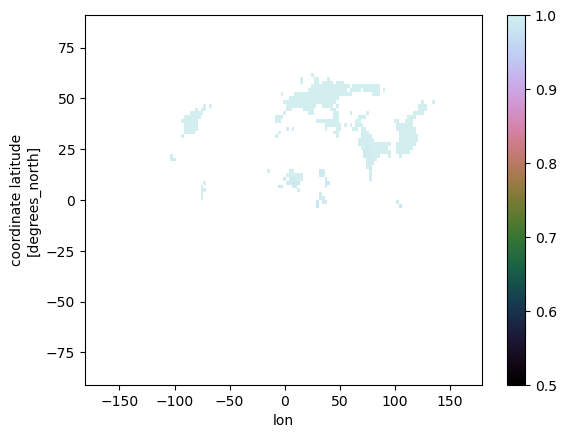

In [11]:
#color= sns.color_palette("salmon")
sbn = sns.color_palette("cubehelix", as_cmap=True)
def truncate_colormap(cmap, minval=0.0, maxval=0.9, n=256):
    new_cmap = LinearSegmentedColormap.from_list(
        "trunc_cubehelix",
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

cmap_trunc = truncate_colormap(sbn, 0.0, 0.9)  # cut off the whitest 10%
corrtv = xr.corr(TSKIN, TV, dim='time')
TSKINsc = TSKIN.where(TV)
TVsc = TV.where(TSKIN)
TSKINvs = TSKINsc.values.flatten()
TVvs = TVsc.values.flatten()
corrtv.plot(vmin=0.5, vmax=1.0, cmap=cmap_trunc)

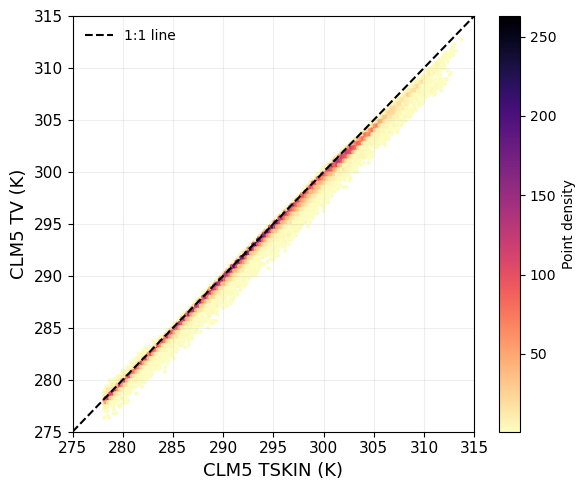

In [34]:
plt.figure(figsize=(6,5))

plt.hexbin(TSKINvs, TVvs, gridsize=150, cmap="magma_r", mincnt=1)

xmin = ymin = 275
xmax = ymax = 315
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.plot([xmin, xmax], [xmin, xmax], 'k--', linewidth=1.5, label="1:1 line")

plt.xlabel("CLM5 TSKIN (K)", fontsize=13)
plt.ylabel("CLM5 TV (K)", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.colorbar(label="Point density")

plt.legend(fontsize=10, frameon=False)
plt.grid(True, alpha=0.2)

plt.savefig(f'/dodrio/scratch/users/vsc10951/sderoos/paper1/figs/RTSKIN_TV_{YR1}_{YR2}.jpeg',dpi=300)

plt.tight_layout()

min: <xarray.DataArray ()>
array(0.39834679) max: <xarray.DataArray ()>
array(0.99442412)


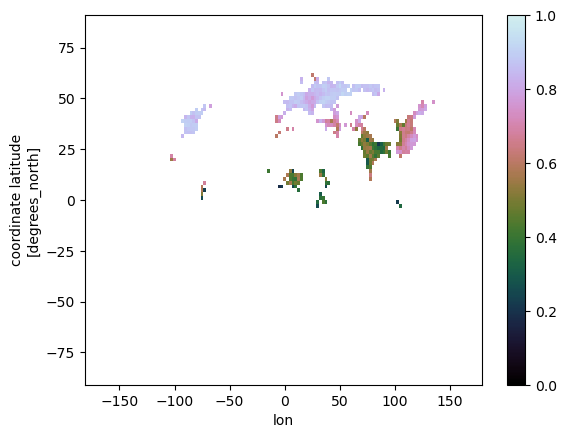

In [19]:

R = xr.corr(TSKIN, LSTM, dim='time')
# anomaly correlation
clim_TSKIN = TSKIN.groupby("time.month").mean(dim="time")
clim_MODIS = LSTM.groupby("time.month").mean(dim="time")
clim_TV= TV.groupby("time.month").mean(dim="time")
# Subtract the monthly climatology
anom_TSKIN = TSKIN.groupby("time.month") - clim_TSKIN
anom_TV = TV.groupby("time.month") - clim_TV
anom_MODIS = LSTM.groupby("time.month") - clim_MODIS
anom_R = xr.corr(anom_TSKIN , anom_MODIS, dim='time')
anom_R.plot(vmin =0.0, vmax=1.0, cmap=cmap_trunc)
print('min:', R.min(), 'max:',R.max())

In [33]:
# Compute RMSE along time dimension
rmse = np.sqrt(((TSKIN- LSTM) ** 2).mean(dim='time'))
anom_rmse = np.sqrt(((anom_TSKIN- anom_MODIS) ** 2).mean(dim='time'))

lat: 0.95 lon: -75.0


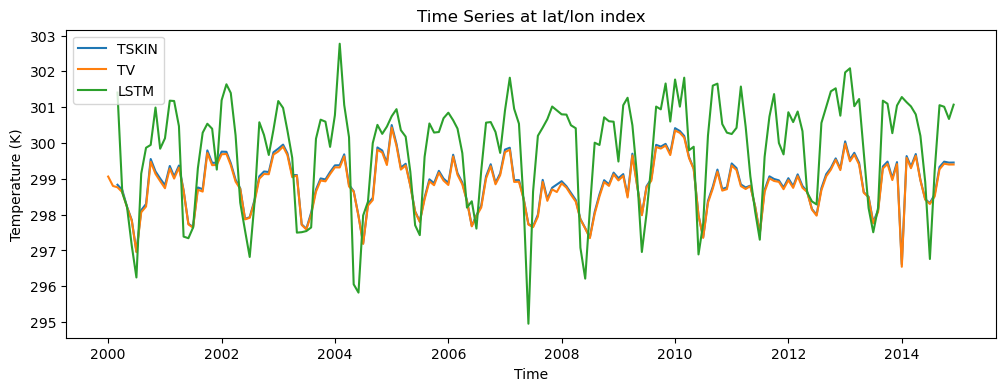

In [57]:
#pcik random valid location
valid_mask = (anom_R<0.4)
lat_idx_all, lon_idx_all = np.where(valid_mask.values)
# 3. Randomly pick one valid index
i = np.random.randint(len(lat_idx_all))
x = lat_idx_all[i]
y = lon_idx_all[i]
#x,y  = 76, 105
latval, lonval = TSKIN['lat'][x].values.round(2), TSKIN['lon'][y].values.round(2)
print('lat:', latval, 'lon:', lonval)
# Convert times to datetime64
time_LSTM = pd.to_datetime(LSTM['time'].values.astype(str))
time_TSKIN = pd.to_datetime(TSKIN['time'].values.astype(str))
time_TV= pd.to_datetime(TV['time'].values.astype(str))

plt.figure(figsize=(12, 4))

plt.plot(time_TSKIN, TSKIN[:, x,y], label='TSKIN')
plt.plot(time_TV, TV[:, x,y], label='TV')
plt.plot(time_LSTM, LSTM[:, x,y], label='LSTM')


plt.xlabel("Time")
plt.ylabel("Temperature (K)")
plt.title("Time Series at lat/lon index")
plt.legend()

plt.savefig(f'/dodrio/scratch/users/vsc10951/sderoos/paper1/figs/LST_CTSM52_MODIS_TS_{latval}_{lonval}_{YR1}_{YR2}.jpeg',dpi=300)
plt.show()

lat: 27.473684 lon: 90.0


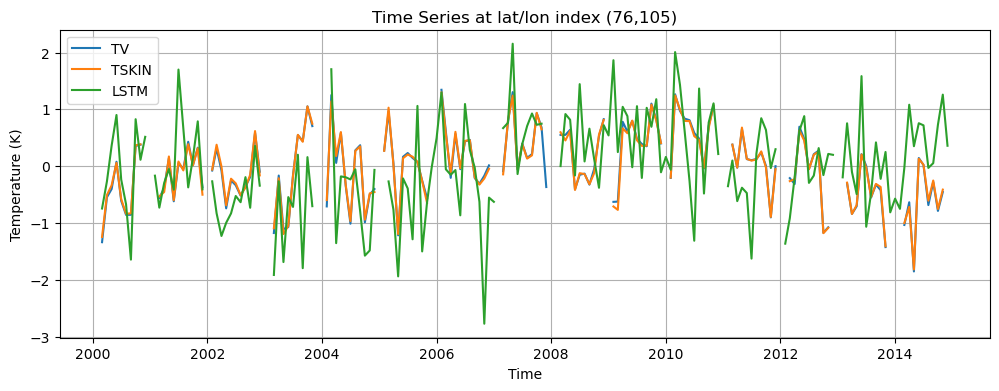

In [54]:

print('lat:', TSKIN['lat'][x].values, 'lon:', TSKIN['lon'][y].values)
# Convert times to datetime64
time_LSTM = pd.to_datetime(anom_MODIS['time'].values.astype(str))
time_TSKIN = pd.to_datetime(anom_TSKIN['time'].values.astype(str))
time_TV= pd.to_datetime(anom_TV['time'].values.astype(str))

plt.figure(figsize=(12, 4))

plt.plot(time_TV, anom_TV[:, x,y], label='TV')
plt.plot(time_TSKIN, anom_TSKIN[:, x,y], label='TSKIN')
plt.plot(time_LSTM, anom_MODIS[:, x,y], label='LSTM')


plt.xlabel("Time")
plt.ylabel("Temperature (K)")
plt.title("Time Series at lat/lon index (76,105)")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_386754/3170174191.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.9,1])  # leave space for colorbars


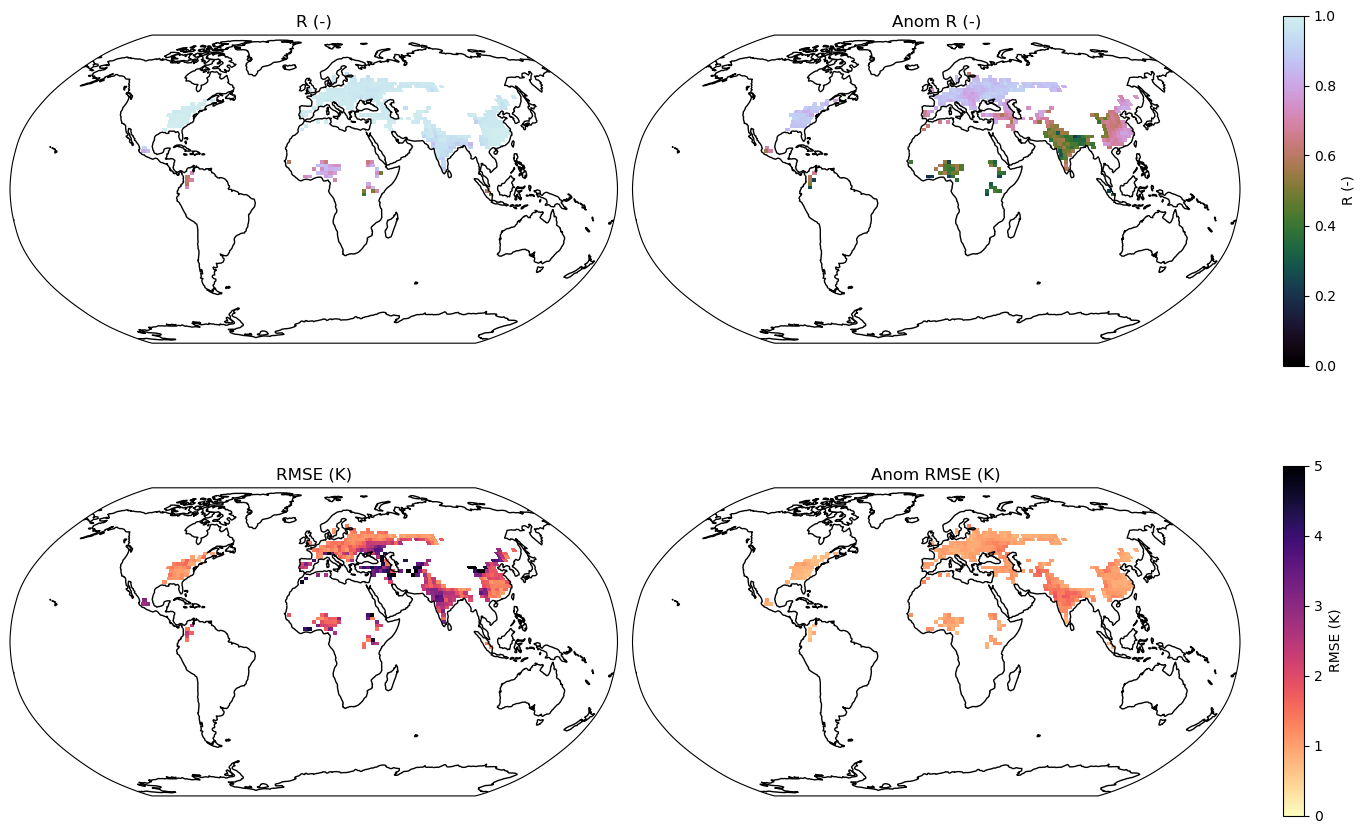

In [34]:
# Example: your datasets
# R, rmse, anom_R, anom_rmse are xarray DataArrays with lat/lon dims
# R, anom_R: range 0-1
# rmse, anom_rmse: range 0-6 (degrees)
# cmap_trunc: your colormap for R
# cmap_rmse: your colormap for RMSE (e.g., "magma" or "viridis")

fig, axes = plt.subplots(
    nrows=2, ncols=2, figsize=(14,10),
    subplot_kw={'projection': ccrs.Robinson()}
)

# Flatten axes for easier indexing
axes = axes.flatten()

# -------------------
# First row: R and RMSE
# -------------------
im0 = R.plot.pcolormesh(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    cmap=cmap_trunc,
    vmin=0.0, vmax=1.0,
    add_colorbar=False
)
axes[0].coastlines()
axes[0].set_title("R (-)")

im1 = rmse.plot.pcolormesh(
    ax=axes[2],
    transform=ccrs.PlateCarree(),
    cmap='magma_r',
    vmin=0.0, vmax=5.0,
    add_colorbar=False
)
axes[2].coastlines()
axes[2].set_title("RMSE (K)")

# -------------------
# Second row: anom_R and anom_RMSE
# -------------------
im2 = anom_R.plot.pcolormesh(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    cmap=cmap_trunc,
    vmin=0.0, vmax=1.0,
    add_colorbar=False
)
axes[1].coastlines()
axes[1].set_title("Anom R (-)")

im3 = anom_rmse.plot.pcolormesh(
    ax=axes[3],
    transform=ccrs.PlateCarree(),
    cmap='magma_r',
    vmin=0.0, vmax=5.0,
    add_colorbar=False
)
axes[3].coastlines()
axes[3].set_title("Anom RMSE (K)")

# -------------------
# Colorbars
# -------------------
# R / anom_R colorbar (shared)
cbar_ax1 = fig.add_axes([0.92, 0.55, 0.015, 0.35])  # [left, bottom, width, height]
cbar1 = fig.colorbar(im0, cax=cbar_ax1)
cbar1.set_label("R (-)")

# RMSE / anom_RMSE colorbar (shared)
cbar_ax2 = fig.add_axes([0.92, 0.1, 0.015, 0.35])
cbar2 = fig.colorbar(im1, cax=cbar_ax2)
cbar2.set_label("RMSE (K)")

plt.tight_layout(rect=[0,0,0.9,1])  # leave space for colorbars
plt.savefig(f'/dodrio/scratch/users/vsc10951/sderoos/paper1/figs/LST_CTSM52_MODIS_{YR1}_{YR2}.jpeg',dpi=300)
plt.show()